<a href="https://www.kaggle.com/code/lalit7881/global-energy-transition-1900-2026-100-acc?scriptVersionId=306588078" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/waddahali/global-energy-transition-and-renewables-1900-2026/owid-energy-data.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/waddahali/global-energy-transition-and-renewables-1900-2026/owid-energy-data.csv")

In [3]:
df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [4]:
df.tail()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
23227,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,NaN,0.0,0.0,0.0,6.440,...,0.298,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
23228,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,NaN,0.0,0.0,0.0,6.963,...,0.233,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
23229,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,NaN,0.0,0.0,0.0,6.845,...,0.336,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
23230,Zimbabwe,2023,ZWE,16340829.0,NaN,NaN,0.0,0.0,0.0,7.344,...,0.361,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
23231,Zimbabwe,2024,ZWE,16634366.0,NaN,NaN,0.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23232 entries, 0 to 23231
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.0+ MB


In [6]:
df.describe()

,year,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
count,23232.000000,1.876000e+04,1.178000e+04,2070.000000,7903.000000,6338.000000,8057.000000,5796.000000,6107.000000,6082.000000,...,7640.000000,6379.000000,2798.000000,6293.000000,6405.000000,8237.000000,9328.000000,5145.000000,7483.000000,6379.000000
mean,1975.937543,1.057591e+08,4.257565e+11,43.478804,1.054261,55.157112,15.092054,71.064594,12.190516,1.962603,...,0.970060,0.219802,290.408294,6.021235,48.691257,68.159540,19.811565,214.958712,1.655011,0.518141
std,35.234386,4.697550e+08,3.507870e+12,286.672317,6.641947,180.660550,75.942529,202.044885,51.641144,5.356652,...,2.961911,0.766125,6070.498582,34.260028,281.755752,275.338849,117.845094,733.879417,4.909754,1.722172
min,1900.000000,1.776000e+03,1.642060e+08,-100.000000,-59.084000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-100.000000,-46.535000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1949.000000,1.600333e+06,1.426394e+10,-0.968000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,2.329000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1985.000000,6.950666e+06,4.357680e+10,6.695500,0.000000,0.000000,0.000000,0.874000,0.020000,0.153500,...,0.000000,0.000000,18.349500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2005.000000,2.575218e+07,1.830576e+11,23.320750,0.000000,0.506750,0.062000,44.114250,0.920000,1.608250,...,0.214750,0.006000,45.210750,0.096000,0.916000,1.855000,0.120000,25.914000,0.565000,0.074500
max,2025.000000,8.161973e+09,1.301126e+14,6373.062000,144.290000,2587.708000,1366.878000,2450.791000,704.810000,77.586000,...,50.000000,9.881000,242384.859000,642.617000,6124.465000,3947.840000,2505.350000,9315.287000,58.357000,26.085000


In [7]:
df.isnull().sum()

country                       0
year                          0
iso_code                   6098
population                 4472
gdp                       11452
                          ...  
wind_elec_per_capita      14995
wind_electricity          13904
wind_energy_per_capita    18087
wind_share_elec           15749
wind_share_energy         16853
Length: 130, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='object', length=130)

In [10]:
df.dtypes

country                    object
year                        int64
iso_code                   object
population                float64
gdp                       float64
                           ...   
wind_elec_per_capita      float64
wind_electricity          float64
wind_energy_per_capita    float64
wind_share_elec           float64
wind_share_energy         float64
Length: 130, dtype: object

In [11]:
df.shape

(23232, 130)

## EDA

In [12]:
df = df.fillna(0)

In [13]:
cols = [
    'year', 'country', 'gdp', 'population',
    'solar_consumption', 'wind_consumption',
    'biofuel_consumption', 'hydro_consumption',
    'coal_consumption', 'oil_consumption',
    'gas_consumption'
]

df_vis = df[cols]


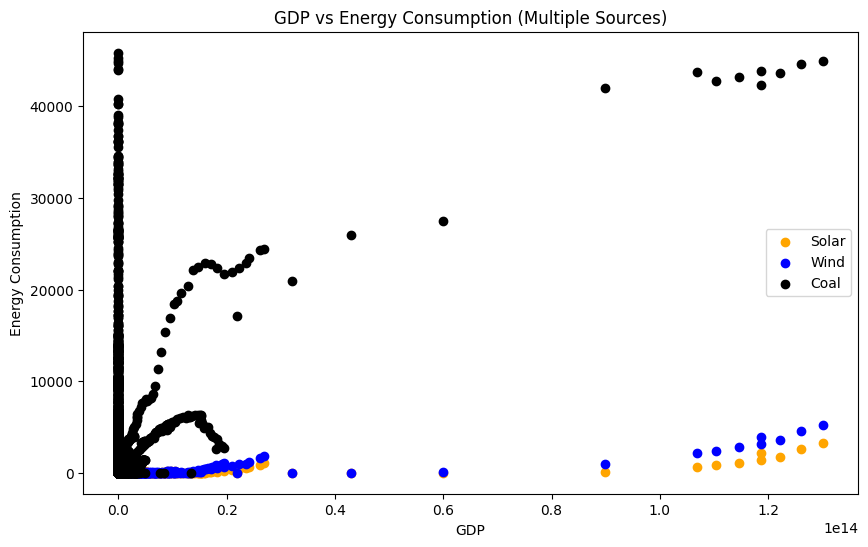

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(df_vis['gdp'], df_vis['solar_consumption'], color='orange', label='Solar')
plt.scatter(df_vis['gdp'], df_vis['wind_consumption'], color='blue', label='Wind')
plt.scatter(df_vis['gdp'], df_vis['coal_consumption'], color='black', label='Coal')
plt.xlabel("GDP")
plt.ylabel("Energy Consumption")
plt.title("GDP vs Energy Consumption (Multiple Sources)")
plt.legend()
plt.show()

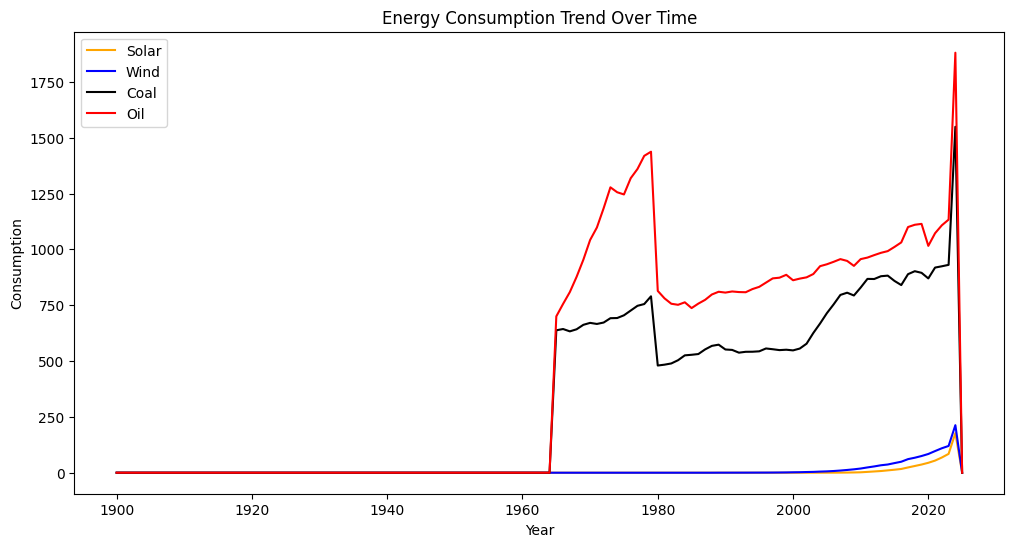

In [15]:
plt.figure(figsize=(12,6))

df_group = df_vis.groupby('year').mean(numeric_only=True)

plt.plot(df_group.index, df_group['solar_consumption'], color='orange', label='Solar')
plt.plot(df_group.index, df_group['wind_consumption'], color='blue', label='Wind')
plt.plot(df_group.index, df_group['coal_consumption'], color='black', label='Coal')
plt.plot(df_group.index, df_group['oil_consumption'], color='red', label='Oil')

plt.title("Energy Consumption Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Consumption")
plt.legend()
plt.show()


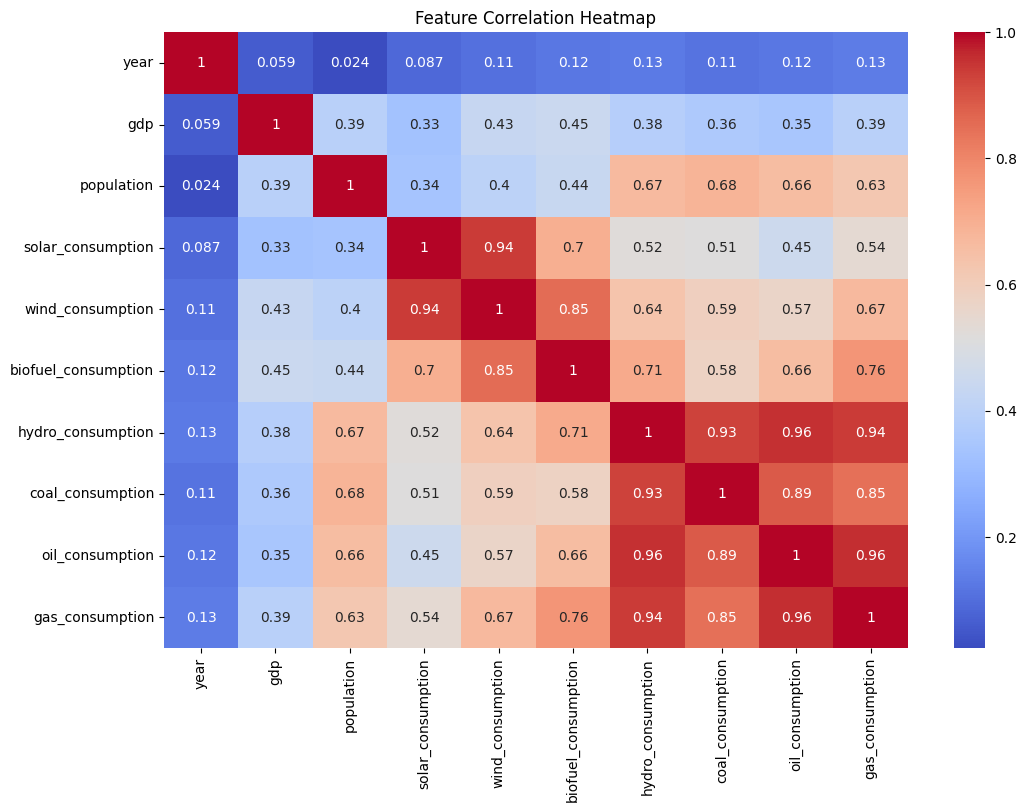

In [16]:
plt.figure(figsize=(12,8))

corr = df_vis.drop(['country'], axis=1).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

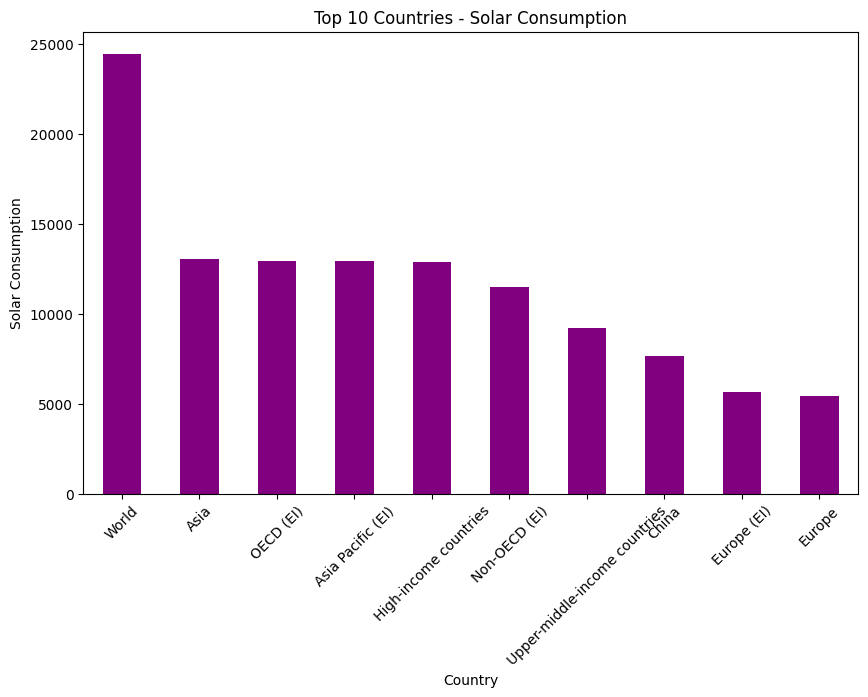

In [17]:
top_countries = df.groupby('country')['solar_consumption'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_countries.plot(kind='bar', color='purple')

plt.title("Top 10 Countries - Solar Consumption")
plt.xlabel("Country")
plt.ylabel("Solar Consumption")
plt.xticks(rotation=45)
plt.show()


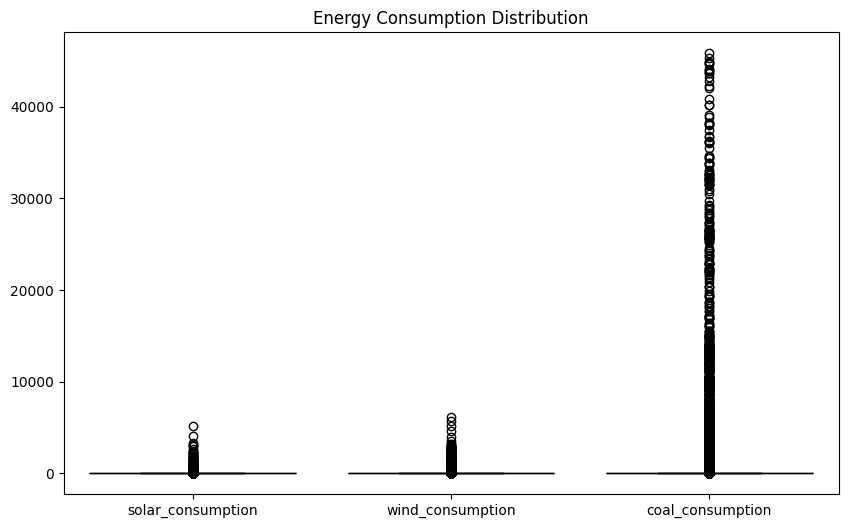

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_vis[['solar_consumption', 'wind_consumption', 'coal_consumption']],
            palette=['orange','blue','black'])

plt.title("Energy Consumption Distribution")
plt.show()


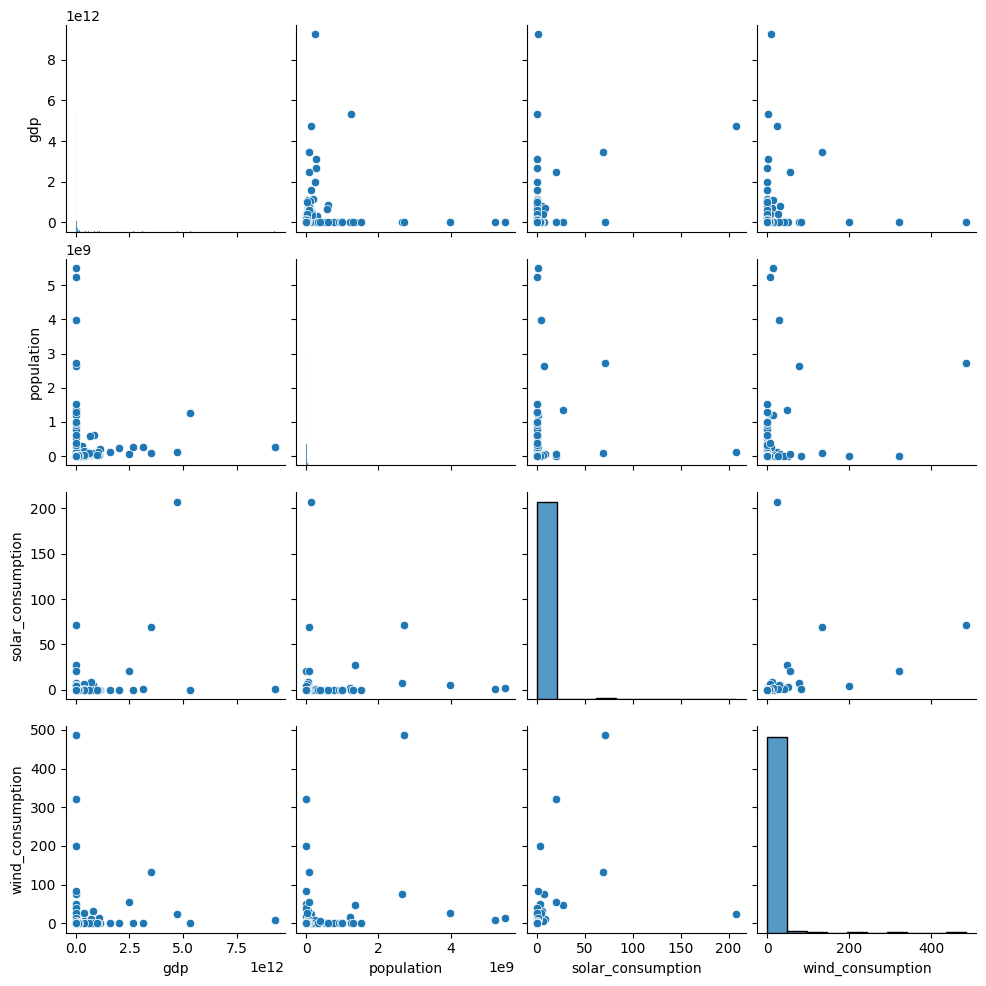

In [19]:
sns.pairplot(df_vis.sample(500), 
             vars=['gdp','population','solar_consumption','wind_consumption'],
             palette='husl')

plt.show()

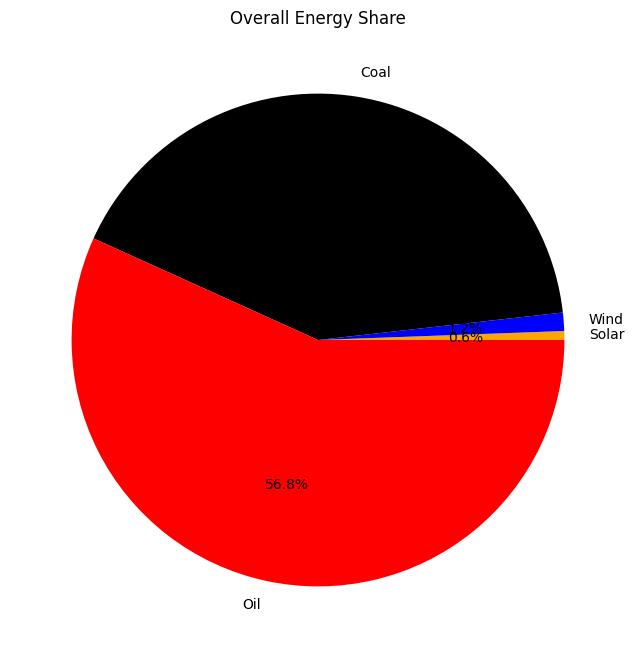

In [20]:
energy_sum = [
    df['solar_consumption'].sum(),
    df['wind_consumption'].sum(),
    df['coal_consumption'].sum(),
    df['oil_consumption'].sum()
]

labels = ['Solar','Wind','Coal','Oil']
colors = ['orange','blue','black','red']

plt.figure(figsize=(8,8))
plt.pie(energy_sum, labels=labels, colors=colors, autopct='%1.1f%%')

plt.title("Overall Energy Share")
plt.show()

## Feature engineering

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

In [22]:
df = df.fillna(0)

df['target'] = (df['renewables_consumption'] > df['renewables_consumption'].median()).astype(int)


In [23]:
leak_cols = ['renewables_consumption', 'target']
X = df.drop(columns=leak_cols)
y = df['target']


In [24]:
# =========================================
# FIX DATA TYPES (VERY IMPORTANT)
# =========================================
categorical_cols = ['country', 'iso_code']

for col in categorical_cols:
    X[col] = X[col].astype(str)

# =========================================
# REMOVE WEIRD VALUES (OPTIONAL CLEANING)
# =========================================
X.replace([np.inf, -np.inf], 0, inplace=True)

# =========================================
# TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# PREPROCESSING
# =========================================
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1)
}


Logistic Regression
Accuracy: 0.9984936518183775
ROC AUC: 0.9997801213247037
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3446
           1       1.00      1.00      1.00      1201

    accuracy                           1.00      4647
   macro avg       1.00      1.00      1.00      4647
weighted avg       1.00      1.00      1.00      4647


Decision Tree
Accuracy: 1.0
ROC AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3446
           1       1.00      1.00      1.00      1201

    accuracy                           1.00      4647
   macro avg       1.00      1.00      1.00      4647
weighted avg       1.00      1.00      1.00      4647


Random Forest
Accuracy: 1.0
ROC AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3446
           1       1.00      1.00      1.00      1201

    accuracy        

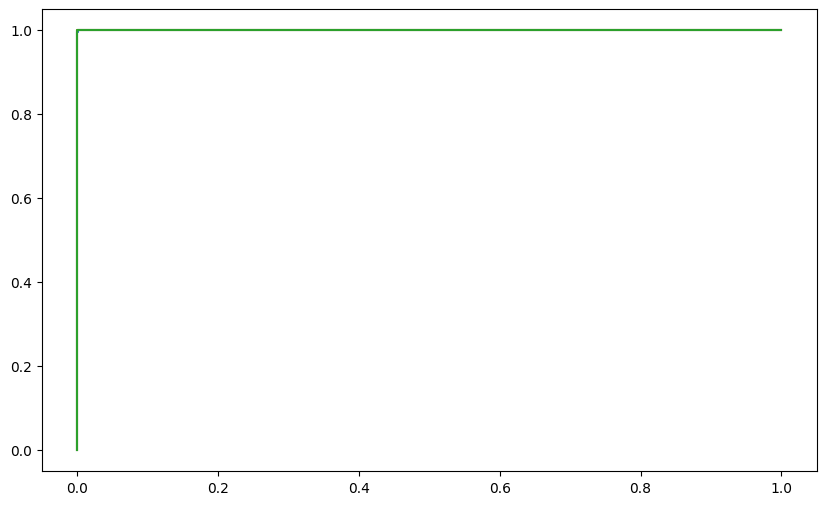

In [25]:
results = {}

plt.figure(figsize=(10,6))

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    
    # TRAIN
    pipeline.fit(X_train, y_train)
    
    # PREDICTIONS
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]
    
    # METRICS
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = [acc, roc_auc]
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("ROC AUC:", roc_auc)
    print(classification_report(y_test, y_pred))
    
    # ROC CURVE
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

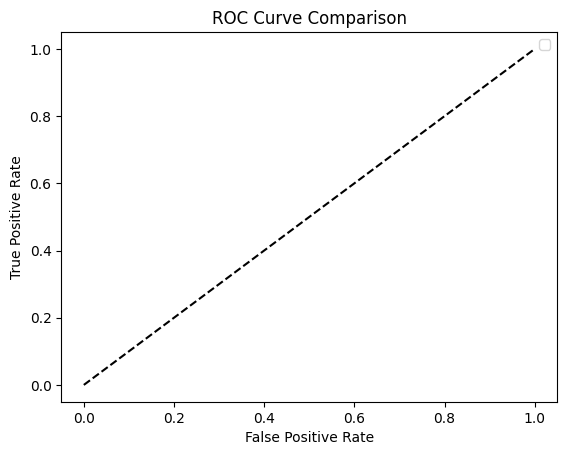

In [26]:
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [27]:
results_df = pd.DataFrame(results, index=['Accuracy', 'ROC AUC']).T

print("\nFinal Model Comparison:")
print(results_df)


Final Model Comparison:
                     Accuracy  ROC AUC
Logistic Regression  0.998494  0.99978
Decision Tree        1.000000  1.00000
Random Forest        1.000000  1.00000


## Thank you...pls upvote!!!!!!!